In [78]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
data_path = Path("../../Data/Original_Data")
data_path_write = Path("../../Data")
mort = 'Complications_and_Deaths-Hospital.csv'
readm = 'Unplanned_Hospital_Visits-Hospital.csv'
safety = 'Healthcare_Associated_Infections-Hospital.csv'
cost = 'Medicare_Hospital_Spending_by_Claim.csv'
hospital = 'Hospital_General_Information.csv'

## Section 1: Executive Summary

The availability and affordability of healthcare is the #1 concern for Americans, according to a March 2026 Gallup poll. [https://news.gallup.com/poll/707732/healthcare-reclaims-top-spot-among-domestic-worries.aspx] People want cost-effective healthcare.  This project analyzes data from the Centers for Medicare & Medicaid Services (CMS) to determine which U.S. hospitals deliver better outcomes at lower costs.


## Section 2: Research Questions

### 1. Are people most likely to find better-outcome / lower-cost healthcare at hospitals in some parts of the U.S. (Census Divisions) more than others?
### 2. Are people most likely to find better-outcome / lower-cost healthcare at hospitals that have a certain type of ownership (for instance, Government or Proprietary)?

## -----------


## Section 3: The Data

#### All data sets are from the Centers for Medicare & Medicaid Services (CMS)
##### Complications_and_Deaths-Hospital.csv (95,780 observations)
    https://data.cms.gov/provider-data/dataset/ynj2-r877
##### Unplanned_Hospital_Visits-Hospital.csv (67,046 observations)
    https://data.cms.gov/provider-data/dataset/632h-zaca
##### Healthcare_Associated_Infections-Hospital.csv (172,404 observations)
    https://data.cms.gov/provider-data/dataset/77hc-ibv8
##### Medicare_Hospital_Spending_by_Claim.csv (63,646 observations)
    https://data.cms.gov/provider-data/dataset/nrth-mfg3
##### Hospital_General_Information.csv (5,426 observations)
    https://data.cms.gov/provider-data/dataset/xubh-q36u

### Data Dictionary
##### Facility_ID: Unique hospital identifier in the form of a six-digit numeric value (ex. 010001). It is a text datatype to accommodate leading zeroes. This is the index.

##### Facility_Name: Name of the hospital. It is a text datatype (ex. MIZELL MEMORIAL HOSPITAL).
##### City_Town: City or town where the hospital is located. It is a text datatype (ex. Denver).
##### State: Two letter state abbreviation for the hospital's location. It is a text datatype (ex. CO).
##### ZIP_Code: Five-digit numeric value for the hospital's location. It has a text datatype to preserve leading 0s (ex. 02354).
##### Census_Division: The Census Division to which a state belongs. There are nine Census Divisions in the U.S. (ex. CO is in the Mountain division). 
##### Hospital_Type: An indicator of the types of services that a hospital provides. It has a text datatype (ex. Acute Care Hospitals).
##### Hospital_Ownership: The type of entity that owns the hospital. It has a text datatype (ex. Voluntary non-profit - Private).
##### Emergency_Services: A binary indicator of whether or not emergency services are provided at the hospital. The two choices are 'Yes' and 'No'.
##### Size_Indicator: A numeric value with a text datatype. CMS rates hospitals in cohorts according to these three sizes (Small, Medium, Large). 
##### Outcomes: A numeric value with a float datatype. This value is calculated from three datasets (Mortality, Readmissions, and Infections) and is in the form of a z-score (ex. 0.234277 or -1.460909).
##### Per_Episode_Cost: A dollar figure with a float datatype (ex. 25745.0). This is the average total cost of an episode for a single hospital patient. It represents the cost in USD of all medical care from 3 days before admission to the hospital to 30 days after discharge from the hospital (this time period constitutes an episode).
##### Value_Quadrant: A text description of the hospital's outcome / cost quadrant. There are 4 possible values: 'high outcome, low cost', 'high outcome, high cost', 'low outcome, low cost', and 'low outcome, high cost'. A hospital with an Outcome score higher than the median value is termed 'high outcome'. All others are 'low outcome'. A hospital with a Per_Episode_Cost lower than the median value is termed 'low cost'. All others are 'high cost'. 

In [3]:
# Reading in the Complications and Deaths file. Two of the measures, COMP_HIP_KNEE and PSI_90, will be combined with the infections
# data to obtain a Safety score. The other measures will be used for the Mortality score.


df_mort_long = pd.read_csv(data_path / mort, usecols = ['Facility ID', 'Measure ID', 'Measure Name', 'Score'])
df_mort_long.columns = (df_mort_long.columns.str.replace(' ', '_'))

df_mort_long = df_mort_long[df_mort_long['Measure_ID'].isin(['COMP_HIP_KNEE',
                                                'MORT_30_AMI',
                                                'MORT_30_CABG',
                                                'MORT_30_COPD',
                                                'MORT_30_HF',
                                                'MORT_30_PN',
                                                'MORT_30_STK',
                                                'PSI_04',
                                                'PSI_90'])]
df_mort_long['Score'] = df_mort_long['Score'].replace('Not Available', np.nan)
df_mort_long = df_mort_long.astype({'Score': 'float'})

In [4]:
df_mort = df_mort_long.pivot(index = 'Facility_ID', columns = 'Measure_ID', values = 'Score')
df_mort = df_mort.reset_index()
df_mort = df_mort.set_index('Facility_ID')
df_mort.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4789 entries, 010001 to 671302
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   COMP_HIP_KNEE  1656 non-null   float64
 1   MORT_30_AMI    1956 non-null   float64
 2   MORT_30_CABG   886 non-null    float64
 3   MORT_30_COPD   2660 non-null   float64
 4   MORT_30_HF     3106 non-null   float64
 5   MORT_30_PN     3649 non-null   float64
 6   MORT_30_STK    2217 non-null   float64
 7   PSI_04         1524 non-null   float64
 8   PSI_90         2920 non-null   float64
dtypes: float64(9)
memory usage: 374.1+ KB


In [5]:
# Reading in the Unplanned Hospital Visits file. These measures will be used for the Readmissions score.

df_readm_long = pd.read_csv(data_path / readm, usecols = ['Facility ID', 'Measure ID', 'Measure Name', 'Score'])
df_readm_long.columns = (df_readm_long.columns.str.replace(' ', '_'))
df_readm_long = df_readm_long[df_readm_long['Measure_ID'].isin (['EDAC_30_AMI',
                                                                 'EDAC_30_HF',
                                                                 'EDAC_30_PN',
                                                                 'READM_30_CABG',
                                                                 'READM_30_COPD',
                                                                 'READM_30_HIP_KNEE',
                                                                 'Hybrid_HWR',
                                                                 'OP_32',
                                                                 'OP_35_ADM',
                                                                 'OP_35_ED',
                                                                 'OP_36'])]
df_readm_long['Score'] = df_readm_long['Score'].replace('Not Available', np.nan)
df_readm_long = df_readm_long.astype({'Score': 'float'})

In [6]:
df_readm_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52679 entries, 0 to 67044
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Facility_ID   52679 non-null  object 
 1   Measure_ID    52679 non-null  object 
 2   Measure_Name  52679 non-null  object 
 3   Score         26662 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.0+ MB


In [7]:
df_readm = df_readm_long.pivot(index = 'Facility_ID', columns = 'Measure_ID', values = 'Score')
df_readm = df_readm.reset_index()
df_readm = df_readm.set_index('Facility_ID')

In [8]:
df_readm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4789 entries, 010001 to 671302
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   EDAC_30_AMI        1555 non-null   float64
 1   EDAC_30_HF         3155 non-null   float64
 2   EDAC_30_PN         3638 non-null   float64
 3   Hybrid_HWR         4217 non-null   float64
 4   OP_32              3152 non-null   float64
 5   OP_35_ADM          1509 non-null   float64
 6   OP_35_ED           1509 non-null   float64
 7   OP_36              2725 non-null   float64
 8   READM_30_CABG      878 non-null    float64
 9   READM_30_COPD      2699 non-null   float64
 10  READM_30_HIP_KNEE  1625 non-null   float64
dtypes: float64(11)
memory usage: 449.0+ KB


In [9]:
# Reading in the Infections file. These measures (along with COMP_HIP_KNEE and PSI_90 from the Complications and Deaths file)
# will be used for the Safety score.

df_safety_long = pd.read_csv(data_path / safety, usecols = ['Facility ID', 'Measure ID', 'Measure Name', 'Score'])
df_safety_long.columns = (df_safety_long.columns.str.replace(' ', '_'))
df_safety_long = df_safety_long[df_safety_long['Measure_ID'].isin(['HAI_1_SIR',
                                                  'HAI_2_SIR',
                                                  'HAI_3_SIR',
                                                  'HAI_4_SIR',
                                                  'HAI_5_SIR',
                                                  'HAI_6_SIR'])]
df_safety_long['Score'] = df_safety_long['Score'].replace('Not Available',np.nan)
df_safety_long = df_safety_long.astype({'Score': 'float'})

In [10]:
df_safety_long.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28734 entries, 5 to 172403
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Facility_ID   28734 non-null  object 
 1   Measure_ID    28734 non-null  object 
 2   Measure_Name  28734 non-null  object 
 3   Score         11272 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.1+ MB


In [11]:
df_safety = df_safety_long.pivot(index = 'Facility_ID', columns = 'Measure_ID', values = 'Score')
df_safety = df_safety.reset_index()
df_safety = df_safety.set_index('Facility_ID')
#df_safety.head(5)

In [12]:
# Moving COMP_HIP_KNEE and PSI_90 from the mort df to the safety df

safety_cols = ['COMP_HIP_KNEE', 'PSI_90']
df_safety[safety_cols] = df_mort[safety_cols]
df_mort = df_mort.drop(columns = safety_cols) 

In [13]:
df_safety.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4789 entries, 010001 to 671302
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HAI_1_SIR      1954 non-null   float64
 1   HAI_2_SIR      2237 non-null   float64
 2   HAI_3_SIR      1776 non-null   float64
 3   HAI_4_SIR      616 non-null    float64
 4   HAI_5_SIR      1713 non-null   float64
 5   HAI_6_SIR      2976 non-null   float64
 6   COMP_HIP_KNEE  1656 non-null   float64
 7   PSI_90         2920 non-null   float64
dtypes: float64(8)
memory usage: 336.7+ KB


### Now that the data is separated into the 3 Category Groups, z-scores will be calculated for each measure individually and then a composite category z-score will be calculated for every hospital.  

#### Z-scores are used so that measures with vastly different ranges can be compared with one another
Z-score = (Hospital score - population mean) / population standard deviation.  Because all measures in these groups have smaller values as better, -1 will be multiplied so that all z-scores show higher values as better.

In [14]:
# Z-scores for all individual measures

mort_measures = ['MORT_30_AMI','MORT_30_CABG', 
                    'MORT_30_COPD','MORT_30_HF',
                    'MORT_30_PN','MORT_30_STK','PSI_04']

readm_measures = ['EDAC_30_AMI','EDAC_30_HF',
                     'EDAC_30_PN','READM_30_CABG',
                     'READM_30_COPD','READM_30_HIP_KNEE',
                     'Hybrid_HWR','OP_32','OP_35_ADM',
                     'OP_35_ED','OP_36']

safety_measures = ['HAI_1_SIR','HAI_2_SIR',
                      'HAI_3_SIR','HAI_4_SIR',
                      'HAI_5_SIR','HAI_6_SIR', 
                      'COMP_HIP_KNEE', 'PSI_90']

mort_z = (-1* (df_mort[mort_measures] - df_mort[mort_measures].mean())) / df_mort[mort_measures].std()
mort_z.columns = [m + '_Z' for m in mort_measures]
df_mort = pd.concat([df_mort, mort_z], axis = 1)

readm_z = (-1*(df_readm[readm_measures] - df_readm[readm_measures].mean())) / df_readm[readm_measures].std()
readm_z.columns = [r + '_Z' for r in readm_measures]
df_readm = pd.concat([df_readm, readm_z], axis = 1)

safety_z = (-1*(df_safety[safety_measures] - df_safety[safety_measures].mean())) / df_safety[safety_measures].std()
safety_z.columns = [s + '_Z' for s in safety_measures]
df_safety = pd.concat([df_safety, safety_z], axis = 1)

In [15]:
df_mort.head(5)
#df_readm.head(5)
#df_safety.head(5)

,MORT_30_AMI,MORT_30_CABG,MORT_30_COPD,MORT_30_HF,MORT_30_PN,MORT_30_STK,PSI_04,MORT_30_AMI_Z,MORT_30_CABG_Z,MORT_30_COPD_Z,MORT_30_HF_Z,MORT_30_PN_Z,MORT_30_STK_Z,PSI_04_Z
Facility_ID,,,,,,,,,,,,,,
010001,11.4,3.0,9.4,10.2,18.4,13.5,203.00,0.635490,-0.407503,-0.337385,0.630422,-0.740382,-0.155884,-1.255617
010005,NaN,NaN,8.9,14.1,21.2,12.9,184.79,NaN,NaN,-0.014865,-1.156534,-1.753173,0.196643,-0.469844
010006,14.5,5.4,8.7,12.5,19.6,12.4,236.12,-2.026588,-3.278654,0.114143,-0.423424,-1.174436,0.490416,-2.684768
010007,NaN,NaN,11.2,13.4,25.4,NaN,NaN,NaN,NaN,-1.498459,-0.835798,-3.272359,NaN,NaN
010008,NaN,NaN,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,NaN,0.489435,NaN,NaN


### For each hospital, an average z-score is calculated for each category group

In [16]:

z_mort_measures = ['MORT_30_AMI_Z','MORT_30_CABG_Z', 
                    'MORT_30_COPD_Z','MORT_30_HF_Z',
                    'MORT_30_PN_Z','MORT_30_STK_Z','PSI_04_Z']

z_readm_measures = ['EDAC_30_AMI_Z','EDAC_30_HF_Z',
                     'EDAC_30_PN_Z','READM_30_CABG_Z',
                     'READM_30_COPD_Z','READM_30_HIP_KNEE_Z',
                     'Hybrid_HWR_Z','OP_32_Z','OP_35_ADM_Z',
                     'OP_35_ED_Z','OP_36_Z']

z_safety_measures = ['HAI_1_SIR_Z','HAI_2_SIR_Z',
                      'HAI_3_SIR_Z','HAI_4_SIR_Z',
                      'HAI_5_SIR_Z','HAI_6_SIR_Z', 
                      'COMP_HIP_KNEE_Z', 'PSI_90_Z']

df_mort['z_mean_mort'] = df_mort[z_mort_measures].mean(axis=1)
df_readm['z_mean_readm'] = df_readm[z_readm_measures].mean(axis=1)
df_safety['z_mean_safety'] = df_safety[z_safety_measures].mean(axis=1)


In [17]:
df_safety.head(5)

,HAI_1_SIR,HAI_2_SIR,HAI_3_SIR,HAI_4_SIR,HAI_5_SIR,HAI_6_SIR,COMP_HIP_KNEE,PSI_90,HAI_1_SIR_Z,HAI_2_SIR_Z,HAI_3_SIR_Z,HAI_4_SIR_Z,HAI_5_SIR_Z,HAI_6_SIR_Z,COMP_HIP_KNEE_Z,PSI_90_Z,z_mean_safety
Facility_ID,,,,,,,,,,,,,,,,,
010001,0.418,0.125,0.292,NaN,0.390,0.395,3.2,0.95,0.287385,0.748472,0.802655,NaN,0.512313,0.001343,0.570855,0.242668,0.452242
010005,1.430,1.054,0.804,NaN,2.431,0.430,3.0,0.97,-1.217619,-1.013994,0.071405,NaN,-2.881029,-0.078448,0.845263,0.139862,-0.590651
010006,0.000,0.105,0.000,0.0,0.200,0.102,4.7,1.14,0.909018,0.786415,1.219696,1.16011,0.828205,0.669310,-1.487205,-0.733989,0.418945
010007,NaN,NaN,NaN,NaN,NaN,0.772,NaN,1.06,NaN,NaN,NaN,NaN,NaN,-0.858124,NaN,-0.322765,-0.590444
010008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Now a master z-score is calculated from all of the hospitals' averages

In [18]:
df_mort['master_mort_z'] = (df_mort['z_mean_mort'] - df_mort['z_mean_mort'].mean()) / df_mort['z_mean_mort'].std()
df_readm['master_readm_z'] = (df_readm['z_mean_readm'] - df_readm['z_mean_readm'].mean()) / df_readm['z_mean_readm'].std()
df_safety['master_safety_z'] = (df_safety['z_mean_safety'] - df_safety['z_mean_safety'].mean()) / df_safety['z_mean_safety'].std()

In [19]:
df_mort_new = df_mort['master_mort_z']
df_readm_new = df_readm['master_readm_z']
df_safety_new = df_safety['master_safety_z']

### Reading in the general hospital data file

In [20]:
df_hospital = pd.read_csv(data_path / hospital, usecols = ['Facility ID', 'Facility Name',
                                                           'City/Town','State','ZIP Code',
                                                           'Hospital Type','Hospital Ownership',
                                                           'Emergency Services','Count of Facility MORT Measures',
                                                           'Count of Facility Safety Measures',
                                                           'Count of Facility READM Measures',
                                                           'Count of Facility Pt Exp Measures',
                                                           'Count of Facility TE Measures'])
df_hospital.columns = (df_hospital.columns.str.replace(' ', '_').str.replace('/', '_'))

hospital_counters = ['Count_of_Facility_MORT_Measures','Count_of_Facility_Safety_Measures',
                     'Count_of_Facility_READM_Measures','Count_of_Facility_Pt_Exp_Measures',
                     'Count_of_Facility_TE_Measures']

df_hospital[hospital_counters] = df_hospital[hospital_counters].replace('Not Available', np.nan)
df_hospital = df_hospital.astype({'ZIP_Code': 'str', 'Count_of_Facility_MORT_Measures': 'float','Count_of_Facility_Safety_Measures': 'float',
                     'Count_of_Facility_READM_Measures': 'float','Count_of_Facility_Pt_Exp_Measures': 'float',
                     'Count_of_Facility_TE_Measures': 'float'})
df_hospital = df_hospital.set_index('Facility_ID')

df_hospital.head(5)

,Facility_Name,City_Town,State,ZIP_Code,Hospital_Type,Hospital_Ownership,Emergency_Services,Count_of_Facility_MORT_Measures,Count_of_Facility_Safety_Measures,Count_of_Facility_READM_Measures,Count_of_Facility_Pt_Exp_Measures,Count_of_Facility_TE_Measures
Facility_ID,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,Acute Care Hospitals,Government - Hospital District or Authority,Yes,7.0,7.0,11.0,8.0,11.0
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,Acute Care Hospitals,Government - Hospital District or Authority,Yes,6.0,7.0,9.0,8.0,12.0
010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,Acute Care Hospitals,Proprietary,Yes,7.0,8.0,9.0,8.0,10.0
010007,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,Acute Care Hospitals,Voluntary non-profit - Private,Yes,3.0,3.0,7.0,8.0,7.0
010008,CRENSHAW COMMUNITY HOSPITAL,LUVERNE,AL,36049,Acute Care Hospitals,Proprietary,Yes,1.0,NaN,2.0,NaN,6.0


In [21]:
df_hospital.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5426 entries, 010001 to 671302
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Facility_Name                      5426 non-null   object 
 1   City_Town                          5426 non-null   object 
 2   State                              5426 non-null   object 
 3   ZIP_Code                           5426 non-null   object 
 4   Hospital_Type                      5426 non-null   object 
 5   Hospital_Ownership                 5426 non-null   object 
 6   Emergency_Services                 5426 non-null   object 
 7   Count_of_Facility_MORT_Measures    3640 non-null   float64
 8   Count_of_Facility_Safety_Measures  3353 non-null   float64
 9   Count_of_Facility_READM_Measures   4266 non-null   float64
 10  Count_of_Facility_Pt_Exp_Measures  3151 non-null   float64
 11  Count_of_Facility_TE_Measures      4486 non-null   flo

## For the CMS star rating methodology, a hospital is included if it has 3 categories with at least 3 ratings per category, provided either Mortality or Safety (or both) are represented. For this analysis, a hospital is included if it has at least 2 of the 3 categories (Mortality, Safety, and Readmissions) with at least 3 ratings in the category.

In [22]:
# next step: define if columns meet thresholds for being included

df_hospital['Mort'] = np.where(df_hospital['Count_of_Facility_MORT_Measures'] >=3,1,0)
df_hospital['Readm'] = np.where(df_hospital['Count_of_Facility_READM_Measures'] >= 3,1,0)
df_hospital['Safety'] = np.where(df_hospital['Count_of_Facility_Safety_Measures'] >= 3,1,0)
df_hospital['Pt_Exp'] = np.where(df_hospital['Count_of_Facility_Pt_Exp_Measures'] >= 3,1,0)
df_hospital['TE'] = np.where(df_hospital['Count_of_Facility_TE_Measures'] >= 3,1,0)
df_hospital['Include'] = df_hospital['Mort'] + df_hospital['Readm'] + df_hospital['Safety']
df_hospital['Size_Indicator'] = (df_hospital['Pt_Exp'] + df_hospital['TE'] + df_hospital['Mort'] 
                            + df_hospital['Readm'] + df_hospital['Safety'])
print(df_hospital['Include'].value_counts())
print(df_hospital['Size_Indicator'].value_counts())
print(df_hospital.shape)

Include
3    2241
0    1812
1     778
2     595
Name: count, dtype: int64
Size_Indicator
5    2228
0    1114
1     657
4     500
2     466
3     461
Name: count, dtype: int64
(5426, 19)


In [23]:
df_hospital_new = df_hospital[df_hospital['Include'] >= 2]
cols_to_drop = ['Count_of_Facility_MORT_Measures', 'Count_of_Facility_Safety_Measures', 'Count_of_Facility_READM_Measures', 
'Count_of_Facility_Pt_Exp_Measures', 'Count_of_Facility_TE_Measures']
df_hospital_new = df_hospital_new.drop(cols_to_drop, axis = 1)
print(df_hospital_new['Include'].value_counts())
print(df_hospital_new.shape)

Include
3    2241
2     595
Name: count, dtype: int64
(2836, 14)


In [24]:
df_hospital_m = pd.merge(df_hospital_new, df_mort_new, left_index = True, right_index = True, how = 'left')
df_hospital_r = pd.merge(df_hospital_m, df_readm_new, left_index = True, right_index = True, how = 'left')
df_hospital_s = pd.merge(df_hospital_r, df_safety_new, left_index = True, right_index = True, how = 'left')
df_hospital_s.head(2)

,Facility_Name,City_Town,State,ZIP_Code,Hospital_Type,Hospital_Ownership,Emergency_Services,Mort,Readm,Safety,Pt_Exp,TE,Include,Size_Indicator,master_mort_z,master_readm_z,master_safety_z
Facility_ID,,,,,,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.222566,0.329290,0.596108
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.778592,1.544932,-0.707939


In [25]:
# Setting z-scores to NaN where there weren't enough measures in the category

df_hospital_s.loc[df_hospital_s['Mort'] == 0, 'master_mort_z'] = np.nan
df_hospital_s.loc[df_hospital_s['Readm'] == 0, 'master_readm_z'] = np.nan
df_hospital_s.loc[df_hospital_s['Safety'] == 0, 'master_safety_z'] = np.nan
df_hospital_s.head(2)

,Facility_Name,City_Town,State,ZIP_Code,Hospital_Type,Hospital_Ownership,Emergency_Services,Mort,Readm,Safety,Pt_Exp,TE,Include,Size_Indicator,master_mort_z,master_readm_z,master_safety_z
Facility_ID,,,,,,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.222566,0.329290,0.596108
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.778592,1.544932,-0.707939


In [26]:
# Taking the average of the three categories' z-scores to obtain a final Outcome measure

df_hospital_s['Outcomes'] = df_hospital_s[['master_mort_z','master_readm_z','master_safety_z']].mean(axis = 1)
df_hospital_s.head(2)

,Facility_Name,City_Town,State,ZIP_Code,Hospital_Type,Hospital_Ownership,Emergency_Services,Mort,Readm,Safety,Pt_Exp,TE,Include,Size_Indicator,master_mort_z,master_readm_z,master_safety_z,Outcomes
Facility_ID,,,,,,,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.222566,0.329290,0.596108,0.234277
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,Acute Care Hospitals,Government - Hospital District or Authority,Yes,1,1,1,1,1,3,5,-0.778592,1.544932,-0.707939,0.019467


### Reading in the Cost data

In [27]:
df_cost = pd.read_csv(data_path / cost)
df_cost.columns = (df_cost.columns.str.replace(' ', '_'))
df_cost['Facility_ID'] = df_cost['Facility_ID'].astype(str).str.zfill(6)

df_cost['Per_Episode_Cost'] = np.where(df_cost['Period'] == 'Complete Episode', df_cost['Avg_Spndg_Per_EP_Hospital'],0)

df_cost = df_cost.groupby('Facility_ID')['Per_Episode_Cost'].sum()

df_cost.info()
df_cost

<class 'pandas.core.series.Series'>
Index: 2893 entries, 010001 to 670333
Series name: Per_Episode_Cost
Non-Null Count  Dtype
--------------  -----
2893 non-null   int64
dtypes: int64(1)
memory usage: 45.2+ KB


Facility_ID
010001    26979
010005    23705
010006    25745
010007    20397
010008    21453
          ...  
670265    40692
670266    30672
670300    29409
670309    28919
670333    24398
Name: Per_Episode_Cost, Length: 2893, dtype: int64

In [28]:
df_hospital_cost = pd.merge(df_hospital_s, df_cost, left_index = True, right_index = True, how = 'left')
df_hospital_cost.shape

(2836, 19)

In [29]:
#df_hospital_cost
df_hospital_cost.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2836 entries, 010001 to 670300
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Facility_Name       2836 non-null   object 
 1   City_Town           2836 non-null   object 
 2   State               2836 non-null   object 
 3   ZIP_Code            2836 non-null   object 
 4   Hospital_Type       2836 non-null   object 
 5   Hospital_Ownership  2836 non-null   object 
 6   Emergency_Services  2836 non-null   object 
 7   Mort                2836 non-null   int64  
 8   Readm               2836 non-null   int64  
 9   Safety              2836 non-null   int64  
 10  Pt_Exp              2836 non-null   int64  
 11  TE                  2836 non-null   int64  
 12  Include             2836 non-null   int64  
 13  Size_Indicator      2836 non-null   int64  
 14  master_mort_z       2725 non-null   float64
 15  master_readm_z      2835 non-null   float64
 16  mast

## There are 2836 non-null Outcome measures but only 2445 non-null Per_Episode_Cost ones. I need both to come up with a score so I will drop all of the rows that lack values for Per_Episode_Cost.

In [30]:
df_hospital_value = df_hospital_cost[df_hospital_cost['Per_Episode_Cost'].notna()]
df_hospital_value.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2445 entries, 010001 to 670300
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Facility_Name       2445 non-null   object 
 1   City_Town           2445 non-null   object 
 2   State               2445 non-null   object 
 3   ZIP_Code            2445 non-null   object 
 4   Hospital_Type       2445 non-null   object 
 5   Hospital_Ownership  2445 non-null   object 
 6   Emergency_Services  2445 non-null   object 
 7   Mort                2445 non-null   int64  
 8   Readm               2445 non-null   int64  
 9   Safety              2445 non-null   int64  
 10  Pt_Exp              2445 non-null   int64  
 11  TE                  2445 non-null   int64  
 12  Include             2445 non-null   int64  
 13  Size_Indicator      2445 non-null   int64  
 14  master_mort_z       2338 non-null   float64
 15  master_readm_z      2444 non-null   float64
 16  mast

In [31]:
# Dropping all of the columns not needed for analysis

cols_to_drop_2 = ['Mort', 'Readm', 'Safety', 'Include', 'master_mort_z', 'master_readm_z', 'master_safety_z', 'Pt_Exp', 'TE']
df_hospital_value = df_hospital_value.drop(cols_to_drop_2, axis = 1)

In [32]:
# Recoding Size Indicator

df_hospital_value['Size_Indicator'] = df_hospital_value['Size_Indicator'].astype(str).replace(to_replace=['3','4','5'], value=['Small','Medium','Large'])

In [33]:
# Adding Census divisions to dataset

new_england = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT']
middle_atlantic = ['NJ', 'NY', 'PA']
east_north_central = ['IL', 'IN', 'MI', 'OH', 'WI']
west_north_central = ['IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']
south_atlantic = ['DE', 'DC', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV']
east_south_central = ['AL', 'KY', 'MS', 'TN']
west_south_central = ['AR', 'LA', 'OK', 'TX']
mountain = ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY']
pacific = ['AK', 'CA', 'HI', 'OR', 'WA']

# making a master state:division dictionary
c_div_map = {state: 'New England' for state in new_england}
c_div_map.update({state: 'Middle Atlantic' for state in middle_atlantic})
c_div_map.update({state: 'East North Central' for state in east_north_central})
c_div_map.update({state: 'West North Central' for state in west_north_central})
c_div_map.update({state: 'South Atlantic' for state in south_atlantic})
c_div_map.update({state: 'East South Central' for state in east_south_central})
c_div_map.update({state: 'West South Central' for state in west_south_central})
c_div_map.update({state: 'Mountain' for state in mountain})
c_div_map.update({state: 'Pacific' for state in pacific})

census_division = df_hospital_value['State'].map(c_div_map)
df_hospital_value.insert(4,'Census_Division', census_division)

In [38]:
df_hospital_value.info()
df_hospital_value.describe()
print(f'\nHospital Sizes: {df_hospital_value['Size_Indicator'].value_counts()}')
print(f'\nOutcomes and Per_Episode_Cost Medians: \n{df_hospital_value[['Outcomes', 'Per_Episode_Cost']].median()}')

<class 'pandas.core.frame.DataFrame'>
Index: 2445 entries, 010001 to 670300
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Facility_Name       2445 non-null   object 
 1   City_Town           2445 non-null   object 
 2   State               2445 non-null   object 
 3   ZIP_Code            2445 non-null   object 
 4   Census_Division     2445 non-null   object 
 5   Hospital_Type       2445 non-null   object 
 6   Hospital_Ownership  2445 non-null   object 
 7   Emergency_Services  2445 non-null   object 
 8   Size_Indicator      2445 non-null   object 
 9   Outcomes            2445 non-null   float64
 10  Per_Episode_Cost    2445 non-null   float64
dtypes: float64(2), object(9)
memory usage: 229.2+ KB

Hospital Sizes: Size_Indicator
Large     2096
Medium     321
Small       28
Name: count, dtype: int64

Outcomes and Per_Episode_Cost Medians: 
Outcomes                0.040326
Per_Episode_Cost    260

In [39]:
outcome_median = df_hospital_value['Outcomes'].median()
cost_median = df_hospital_value['Per_Episode_Cost'].median()

outcome_ind = np.where(df_hospital_value['Outcomes'] > outcome_median, 'high outcome', 'low outcome')
cost_ind = np.where(df_hospital_value['Per_Episode_Cost'] < cost_median, 'low cost', 'high cost')

df_hospital_value['Value_Quadrant'] = outcome_ind + ' , ' + cost_ind

df_hospital_value.head(4)


The Median Outcome is 0.04
The Median Cost is 26038.00


,Facility_Name,City_Town,State,ZIP_Code,Census_Division,Hospital_Type,Hospital_Ownership,Emergency_Services,Size_Indicator,Outcomes,Per_Episode_Cost,Value_Quadrant
Facility_ID,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,East South Central,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Large,0.234277,26979.0,"high outcome , high cost"
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,East South Central,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Large,0.019467,23705.0,"low outcome , low cost"
010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,East South Central,Acute Care Hospitals,Proprietary,Yes,Large,-0.387232,25745.0,"low outcome , low cost"
010007,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,East South Central,Acute Care Hospitals,Voluntary non-profit - Private,Yes,Large,-1.460909,20397.0,"low outcome , low cost"


In [40]:
df_hospital_value.head(2)

,Facility_Name,City_Town,State,ZIP_Code,Census_Division,Hospital_Type,Hospital_Ownership,Emergency_Services,Size_Indicator,Outcomes,Per_Episode_Cost,Value_Quadrant
Facility_ID,,,,,,,,,,,,
010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,East South Central,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Large,0.234277,26979.0,"high outcome , high cost"
010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,East South Central,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Large,0.019467,23705.0,"low outcome , low cost"


In [41]:
# Writing clean data to csv file

df_hospital_value.to_csv(data_path_write / 'hospital_value_clean.csv')

## Section 4: Data Exploration



In [45]:
# Counts of categorical variables

census_vals = df_hospital_value['Census_Division'].value_counts()
type_vals = df_hospital_value['Hospital_Type'].value_counts()
ownership_vals = df_hospital_value['Hospital_Ownership'].value_counts()
emer_vals = df_hospital_value['Emergency_Services'].value_counts()
size_vals = df_hospital_value['Size_Indicator'].value_counts()
quad_vals = df_hospital_value['Value_Quadrant'].value_counts()

print(f' \nStates Represented: {census_vals}')
print(f' \nHospital Types: {type_vals}')
print(f' \nHospital Ownership Designations: {ownership_vals}')
print(f' \nEmergency Services Offered?: {emer_vals}')
print(f' \nSize Indicator: {size_vals}')
print(f' \nValue Quadrant: {quad_vals}')

 
States Represented: Census_Division
South Atlantic        449
East North Central    405
West South Central    311
Pacific               309
Middle Atlantic       289
East South Central    202
West North Central    190
Mountain              174
New England           116
Name: count, dtype: int64
 
Hospital Types: Hospital_Type
Acute Care Hospitals    2445
Name: count, dtype: int64
 
Hospital Ownership Designations: Hospital_Ownership
Voluntary non-profit - Private                 1261
Proprietary                                     453
Voluntary non-profit - Other                    211
Voluntary non-profit - Church                   185
Government - Hospital District or Authority     161
Government - Local                              113
Government - State                               35
Physician                                        18
Government - Federal                              8
Name: count, dtype: int64
 
Emergency Services Offered?: Emergency_Services
Yes    2325
No   

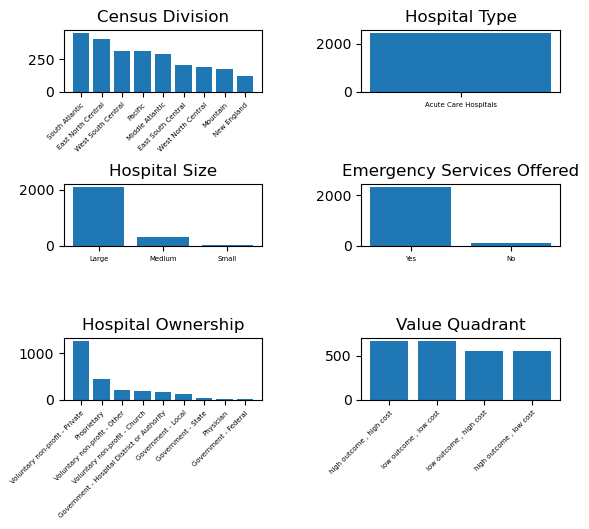

In [54]:
plt.subplots_adjust(hspace=1.5, wspace=.5)

plt.subplot(3, 2, 1)
plt.bar(census_vals.index, census_vals.values)
plt.title('Census Division')
plt.xticks(rotation=45, fontsize = 5, ha='right', rotation_mode='anchor')

plt.subplot(3, 2, 2)
plt.bar(type_vals.index, type_vals.values)
plt.title('Hospital Type')
plt.xticks(fontsize = 5)




plt.subplot(3, 2, 3)
plt.bar(size_vals.index, size_vals.values)
plt.title('Hospital Size')
plt.xticks(fontsize = 5)


plt.subplot(3, 2, 4)
plt.bar(emer_vals.index, emer_vals.values)
plt.title('Emergency Services Offered')
plt.xticks(fontsize = 5)


plt.subplot(3, 2, 5)
plt.bar(ownership_vals.index, ownership_vals.values) 
plt.title('Hospital Ownership')
plt.xticks(rotation=45, fontsize = 5, ha='right', rotation_mode='anchor')


plt.subplot(3, 2, 6)
plt.bar(quad_vals.index, quad_vals.values)
plt.title('Value Quadrant')
plt.xticks(rotation=45, fontsize = 5, ha='right', rotation_mode='anchor')

plt.show()


In [59]:
# Summary stats of continuous variables

print(f'\nThe Median Outcome is {outcome_median:.2f}')
print(df_hospital_value['Outcomes'].describe())

print(f'\nThe Median Cost is {cost_median:.2f}')
print(df_hospital_value['Per_Episode_Cost'].describe())



The Median Outcome is 0.04
count    2445.000000
mean        0.024394
std         0.520694
min        -4.364340
25%        -0.291223
50%         0.040326
75%         0.349648
max         3.232125
Name: Outcomes, dtype: float64

The Median Cost is 26038.00
count     2445.000000
mean     26124.914519
std       3742.572192
min      13638.000000
25%      23634.000000
50%      26038.000000
75%      28539.000000
max      44537.000000
Name: Per_Episode_Cost, dtype: float64


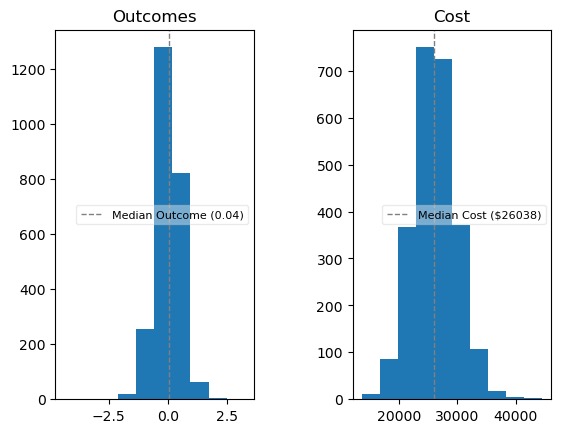

In [77]:
plt.subplots_adjust(wspace=.5, hspace=1.5)

plt.subplot(1, 2, 1)
plt.hist(df_hospital_value['Outcomes'])
plt.title('Outcomes')
plt.axvline(x = outcome_median, color='gray', linestyle='--', linewidth=1, label=f'Median Outcome ({outcome_median:.2f})')
plt.legend(loc='center right', fontsize=8, framealpha=0.4)

plt.subplot(1, 2, 2)
plt.hist(df_hospital_value['Per_Episode_Cost'])
plt.title('Cost')
plt.axvline(x = cost_median, color='gray', linestyle='--', linewidth=1, label=f'Median Cost (\${cost_median:.0f})')
plt.legend(loc='center right', fontsize=8, framealpha=0.4)

_=plt.show()

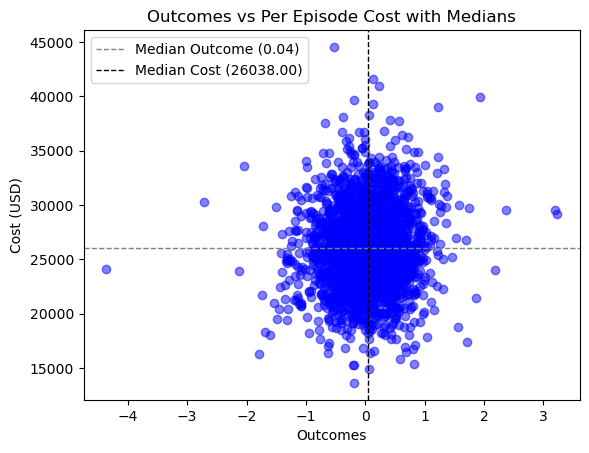

In [68]:
plt.scatter(df_hospital_value['Outcomes'],df_hospital_value['Per_Episode_Cost'],color = 'blue', alpha = 0.5)
plt.title('Outcomes vs Per Episode Cost with Medians')
plt.xlabel('Outcomes')
plt.ylabel('Cost (USD)')
plt.axhline(y = cost_median, color='gray', linestyle='--', linewidth=1, label=f'Median Outcome ({outcome_median:.2f})')
plt.axvline(x = outcome_median, color='black', linestyle='--', linewidth=1, label=f'Median Cost ({cost_median:.2f})')
plt.legend()
plt.show()

In [85]:
# For each Census Division looking at the percentage of those hospitals in each value quadrant (percentages in rows sum to 1)

pd.crosstab(df_hospital_value['Census_Division'], df_hospital_value['Value_Quadrant'], normalize = 'index')

Value_Quadrant,"high outcome , high cost","high outcome , low cost","low outcome , high cost","low outcome , low cost"
Census_Division,,,,
East North Central,0.244444,0.286420,0.187654,0.281481
East South Central,0.128713,0.173267,0.297030,0.400990
Middle Atlantic,0.294118,0.197232,0.252595,0.256055
Mountain,0.367816,0.275862,0.189655,0.166667
New England,0.198276,0.327586,0.120690,0.353448
Pacific,0.343042,0.184466,0.245955,0.226537
South Atlantic,0.224944,0.267261,0.211581,0.296214
West North Central,0.236842,0.278947,0.142105,0.342105
West South Central,0.376206,0.102894,0.331190,0.189711


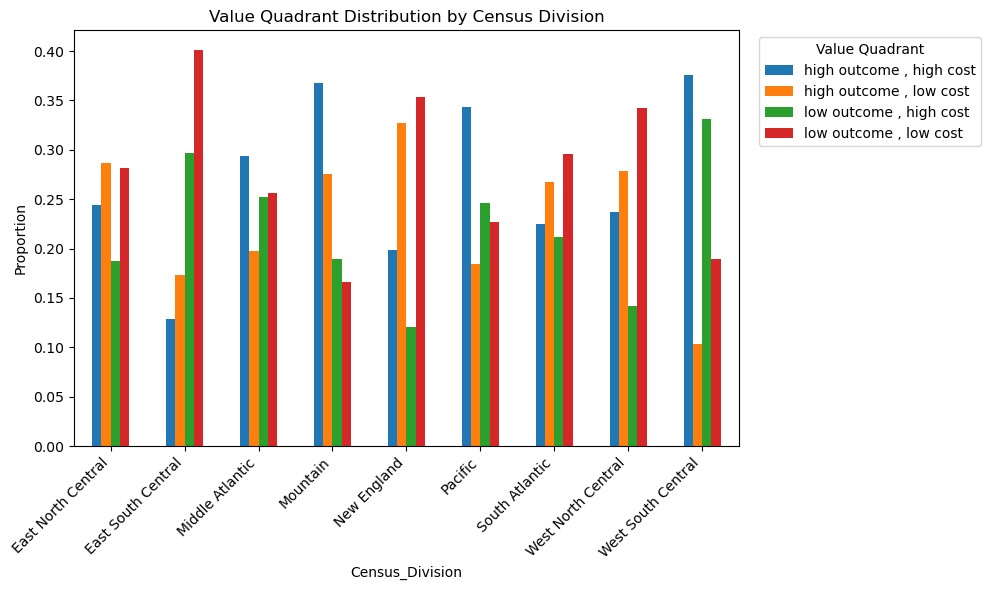

In [94]:
ct1 = pd.crosstab(df_hospital_value['Census_Division'], 
                 df_hospital_value['Value_Quadrant'], 
                 normalize='index')
ct1.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.ylabel('Proportion')
plt.title('Value Quadrant Distribution by Census Division')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Value Quadrant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [86]:
# For each Ownership Type looking at the percentage of those hospitals in each value quadrant (percentages in rows sum to 1)

pd.crosstab(df_hospital_value['Hospital_Ownership'], df_hospital_value['Value_Quadrant'], normalize = 'index')

Value_Quadrant,"high outcome , high cost","high outcome , low cost","low outcome , high cost","low outcome , low cost"
Hospital_Ownership,,,,
Government - Federal,0.125000,0.250000,0.250000,0.375000
Government - Hospital District or Authority,0.161491,0.229814,0.229814,0.378882
Government - Local,0.106195,0.230088,0.230088,0.433628
Government - State,0.314286,0.114286,0.428571,0.142857
Physician,0.611111,0.055556,0.222222,0.111111
Proprietary,0.282561,0.178808,0.309051,0.229581
Voluntary non-profit - Church,0.372973,0.248649,0.194595,0.183784
Voluntary non-profit - Other,0.208531,0.317536,0.165877,0.308057
Voluntary non-profit - Private,0.288660,0.231562,0.207772,0.272006


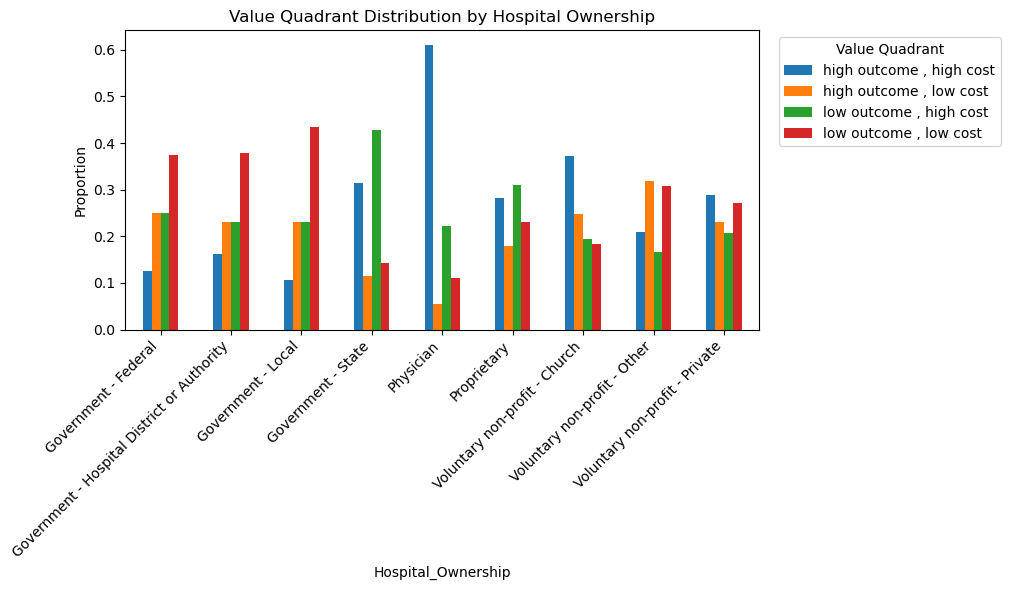

In [93]:
ct2 = pd.crosstab(df_hospital_value['Hospital_Ownership'], 
                 df_hospital_value['Value_Quadrant'], 
                 normalize='index')
ct2.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.ylabel('Proportion')
plt.title('Value Quadrant Distribution by Hospital Ownership')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Value Quadrant', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()